# Prediccion de mortalidad intrahospitalaria por causas cardiacas
## Egresos hospitalarios de Chile 2020 con Apache Spark + Oversampling

Proyecto **CRISP-DM** completo en un solo notebook. Procesamiento y modelado distribuido
con **Apache Spark MLlib**.

**Dataset:** `EGRE_DATOS_ABIERTOS_2020.csv` (~246 MB, 1.33 M filas).

### Manejo del desbalance de clases

El subconjunto cardiaco tiene ~6% de mortalidad. Se aplica una **doble estrategia**:

1. **Oversampling de la clase minoritaria (fallecidos)** sobre el train, replicando las
   filas con label=1 hasta equilibrar el conteo con la clase mayoritaria.
2. **`classWeight`** en el entrenamiento, que en la practica refuerza el oversampling y
   ayuda a los modelos lineales a converger correctamente.

El **test NUNCA se balancea** — debe reflejar la distribucion real de la poblacion para
que las metricas sean validas.

---

### Indice

1. **Fase 1** - Entendimiento del Negocio
2. **Fase 2** - Entendimiento de los Datos
3. **Fase 3** - Preparacion de los Datos (Pipeline + Oversampling)
4. **Fase 4** - Modelado
   - 4.1 Baseline: Arbol de decision
   - 4.2 LinearSVC con regularizacion L2 + tuning con CV
   - 4.3 Bagging manual con DecisionTreeClassifier
   - 4.4 GBTClassifier + tuning con CV
5. **Fase 5** - Evaluacion comparativa
6. **Fase 6** - Despliegue y conclusiones

## 0. Verificacion del entorno

In [1]:
import sys, platform
print(f"Python version: {sys.version}")
print(f"Plataforma:     {platform.platform()}")
if sys.version_info[:2] not in [(3, 11), (3, 10), (3, 9)]:
    print("\nADVERTENCIA: PySpark 3.5.1 esta probado oficialmente con Python 3.9-3.11.")
else:
    print("\nVersion de Python compatible con PySpark 3.5.1.")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Plataforma:     Windows-10-10.0.26200-SP0

Version de Python compatible con PySpark 3.5.1.


## Fase 1 - Entendimiento del Negocio

**Problema real.** En Chile, las enfermedades del sistema circulatorio (CIE-10 capitulo IX,
codigos `I00`-`I99`) son la primera causa de muerte. Identificar tempranamente los pacientes
con mayor riesgo de mortalidad intrahospitalaria por causa cardiaca permite priorizar camas
criticas, asignar especialistas y reducir mortalidad evitable.

**Objetivo analitico.** Predecir la **probabilidad de mortalidad intrahospitalaria** entre
pacientes egresados con diagnostico principal cardiovascular.

**Pregunta de negocio -> problema de ML.**
*"Cual es la probabilidad de que un paciente con diagnostico cardiaco principal fallezca
durante su hospitalizacion?"* -> **Clasificacion binaria** sobre `CONDICION_EGRESO`
(1 = Vivo, 2 = Fallecido), filtrando previamente por `DIAG1` perteneciente al capitulo I00-I99.

**Metrica principal:** AUC-ROC (apta para clases desbalanceadas, ~6% mortalidad).
**Metricas secundarias:** AUC-PR, F1, Recall de la clase positiva.

## Configuracion inicial

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Forzar que PySpark use el mismo Python del notebook
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import (DecisionTreeClassifier, LinearSVC, GBTClassifier)
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                   MulticlassClassificationEvaluator)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array
from pyspark.ml.linalg import Vectors, VectorUDT

CSV_PATH = ["EGRE_DATOS_ABIERTOS_2020.csv", "EGRE_DATOS_ABIERTOS_2021.csv", "EGRE_DATOS_ABIERTOS_2022.csv"]

tamaño_total_bytes = sum(os.path.getsize(archivo) for archivo in CSV_PATH)
tamaño_mb = tamaño_total_bytes / (1024 * 1024)

print(f"Tamaño total de los datasets: {tamaño_mb:.2f} MB")

Tamaño total de los datasets: 785.27 MB


### Inicializar SparkSession

In [3]:
JAVA_OPTS = " ".join([
    "--add-opens=java.base/java.lang=ALL-UNNAMED",
    "--add-opens=java.base/java.lang.invoke=ALL-UNNAMED",
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED",
    "--add-opens=java.base/java.io=ALL-UNNAMED",
    "--add-opens=java.base/java.net=ALL-UNNAMED",
    "--add-opens=java.base/java.nio=ALL-UNNAMED",
    "--add-opens=java.base/java.util=ALL-UNNAMED",
    "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED",
    "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED",
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED",
    "--add-opens=java.base/sun.security.action=ALL-UNNAMED",
    "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED",
])

spark = (
    SparkSession.builder
    .appName("MortalidadCardiaca2020")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.driver.extraJavaOptions", JAVA_OPTS)
    .config("spark.executor.extraJavaOptions", JAVA_OPTS)
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
spark

Spark version: 4.1.1


## Fase 2 - Entendimiento de los Datos

### 2.1 Carga del CSV

In [4]:
df_raw = (
    spark.read
    .option("header", True)
    .option("sep", ";")
    .option("encoding", "ISO-8859-1")
    .option("inferSchema", True)
    .csv(CSV_PATH)
)

print("Filas:", f"{df_raw.count():,}")
print("Columnas:", len(df_raw.columns))
df_raw.printSchema()

Filas: 4,394,657
Columnas: 18
root
 |-- PERTENENCIA_ESTABLECIMIENTO_SALUD: string (nullable = true)
 |-- SEXO: string (nullable = true)
 |-- GRUPO_EDAD: string (nullable = true)
 |-- ETNIA: string (nullable = true)
 |-- GLOSA_PAIS_ORIGEN: string (nullable = true)
 |-- COMUNA_RESIDENCIA: string (nullable = true)
 |-- GLOSA_COMUNA_RESIDENCIA: string (nullable = true)
 |-- REGION_RESIDENCIA: string (nullable = true)
 |-- GLOSA_REGION_RESIDENCIA: string (nullable = true)
 |-- PREVISION: string (nullable = true)
 |-- GLOSA_PREVISION: string (nullable = true)
 |-- ANO_EGRESO: string (nullable = true)
 |-- DIAG1: string (nullable = true)
 |-- DIAG2: string (nullable = true)
 |-- DIAS_ESTADA: string (nullable = true)
 |-- CONDICION_EGRESO: string (nullable = true)
 |-- INTERV_Q: string (nullable = true)
 |-- PROCED: string (nullable = true)



In [5]:
df_raw.show(3, truncate=False)

+-----------------------------------------------------------------+------+----------+---------------------------------+-----------------+-----------------+-----------------------+-----------------+-----------------------+---------+---------------+----------+-----+-----+-----------+----------------+--------+------+
|PERTENENCIA_ESTABLECIMIENTO_SALUD                                |SEXO  |GRUPO_EDAD|ETNIA                            |GLOSA_PAIS_ORIGEN|COMUNA_RESIDENCIA|GLOSA_COMUNA_RESIDENCIA|REGION_RESIDENCIA|GLOSA_REGION_RESIDENCIA|PREVISION|GLOSA_PREVISION|ANO_EGRESO|DIAG1|DIAG2|DIAS_ESTADA|CONDICION_EGRESO|INTERV_Q|PROCED|
+-----------------------------------------------------------------+------+----------+---------------------------------+-----------------+-----------------+-----------------------+-----------------+-----------------------+---------+---------------+----------+-----+-----+-----------+----------------+--------+------+
|No Pertenecientes al Sistema Nacional de Servicios 

### 2.2 Filtrado al subconjunto de interes (causas cardiacas)

Capitulo IX de la CIE-10: `I00`-`I99`. Incluye infarto agudo (`I21`), insuficiencia
cardiaca (`I50`), fibrilacion auricular (`I48`), enfermedad hipertensiva (`I10`-`I15`), etc.

In [6]:
df = df_raw.filter(F.col("DIAG1").rlike("^I[0-9]"))
n_card = df.count()
print(f"Casos cardiacos: {n_card:,}")
print(f"Porcentaje del total: {n_card / df_raw.count() * 100:.2f}%")

Casos cardiacos: 249,593
Porcentaje del total: 5.68%


### 2.3 Distribucion de la variable objetivo

In [7]:
df.groupBy("CONDICION_EGRESO").count().orderBy("CONDICION_EGRESO").show()
tasa = df.agg(
    (F.sum(F.when(F.col("CONDICION_EGRESO") == 2, 1).otherwise(0)) / F.count("*")).alias("tasa")
).collect()[0]["tasa"]
print(f"Tasa de mortalidad intrahospitalaria cardiaca: {tasa*100:.2f}%")

+----------------+------+
|CONDICION_EGRESO| count|
+----------------+------+
|               1|234818|
|               2| 14775|
+----------------+------+

Tasa de mortalidad intrahospitalaria cardiaca: 5.92%


**Observacion:** desbalance moderado (~6% de fallecidos). Lo trataremos con **oversampling**
del train + `classWeight` en los modelos.

### 2.4 EDA con funciones nativas de Spark

In [8]:
(df.groupBy("SEXO")
   .agg(F.count("*").alias("n"),
        (F.avg(F.when(F.col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0)) * 100).alias("%_falle"))
   .orderBy(F.desc("n")).show())

+------+------+------------------+
|  SEXO|     n|           %_falle|
+------+------+------------------+
|HOMBRE|138917| 5.532800161247364|
| MUJER|105226| 6.405261057153175|
|     *|  5450|6.4036697247706424|
+------+------+------------------+



In [9]:
(df.groupBy("GRUPO_EDAD")
   .agg(F.count("*").alias("n"),
        (F.avg(F.when(F.col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0)) * 100).alias("%_falle"))
   .orderBy(F.desc("%_falle")).show(20, truncate=False))

+---------------+-----+------------------+
|GRUPO_EDAD     |n    |%_falle           |
+---------------+-----+------------------+
|90 y más       |8306 |15.43462557187575 |
|80 a 89        |37432|10.290660397520837|
|70 a 79        |59360|6.649258760107816 |
|*              |5450 |6.4036697247706424|
|60 a 69        |60553|4.787541492576751 |
|menor de un año|415  |3.8554216867469884|
|50 a 59        |40087|3.5447900815725797|
|40 a 49        |19971|3.229683040408592 |
|30 a 39        |9795 |2.184788157223073 |
|1 a 9          |1231 |2.1121039805036554|
|20 a 29        |4590 |1.8518518518518516|
|10 a 19        |2403 |1.6229712858926344|
+---------------+-----+------------------+



In [10]:
(df.groupBy("DIAG1")
   .agg(F.count("*").alias("n"),
        (F.avg(F.when(F.col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0)) * 100).alias("%_falle"))
   .orderBy(F.desc("n")).show(15))

+-----+-----+------------------+
|DIAG1|    n|           %_falle|
+-----+-----+------------------+
| I219|15937|  7.43552738909456|
| I500|14784|  7.71780303030303|
| I509|11606| 8.038945373082889|
| I64X| 9954|10.206951979103877|
| I269| 9364| 7.731738573259291|
| I678| 9329| 7.224782934934076|
| I200| 8548|0.7370145063172672|
| I639| 7987| 6.498059346437962|
| I489| 7736|2.0682523267838677|
| I839| 7699|0.0129886998311469|
| I251| 6721| 1.978872191638149|
| I214| 5271|  4.59115917283248|
| I802| 4677|0.8980115458627326|
| I442| 4279|3.1549427436316897|
| I635| 4163|  7.20634158059092|
+-----+-----+------------------+
only showing top 15 rows


In [11]:
df.groupBy("CONDICION_EGRESO").agg(
    F.count("*").alias("n"),
    F.round(F.avg("DIAS_ESTADA"), 2).alias("media"),
    F.expr("percentile_approx(DIAS_ESTADA, 0.5)").alias("mediana"),
    F.min("DIAS_ESTADA").alias("min"),
    F.max("DIAS_ESTADA").alias("max"),
).show()

+----------------+------+-----+-------+---+---+
|CONDICION_EGRESO|     n|media|mediana|min|max|
+----------------+------+-----+-------+---+---+
|               1|234818| 8.72|    5.0|  1| 99|
|               2| 14775| 14.3|    5.0|  1| 98|
+----------------+------+-----+-------+---+---+



### 2.5 Identificacion de problemas en los datos

In [12]:
exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
df_nulos = df.agg(*exprs).toPandas().T.rename(columns={0: "nulos"})
df_nulos["%"] = (df_nulos["nulos"] / n_card * 100).round(2)
df_nulos.sort_values("nulos", ascending=False)

c:\Users\k0mi\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,nulos,%
DIAG2,249593,100.00
INTERV_Q,111146,44.53
PROCED,110324,44.20
PERTENENCIA_ESTABLECIMIENTO_SALUD,0,0.00
SEXO,0,0.00
GRUPO_EDAD,0,0.00
GLOSA_COMUNA_RESIDENCIA,0,0.00
ETNIA,0,0.00
GLOSA_PAIS_ORIGEN,0,0.00
COMUNA_RESIDENCIA,0,0.00


In [13]:
df.select("DIAS_ESTADA").describe().show()
print("Casos con DIAS_ESTADA negativo:", df.filter(F.col("DIAS_ESTADA") < 0).count())
print("Casos con DIAS_ESTADA > 365:", df.filter(F.col("DIAS_ESTADA") > 365).count())

+-------+-----------------+
|summary|      DIAS_ESTADA|
+-------+-----------------+
|  count|           249593|
|   mean|9.050418080635275|
| stddev|43.18510523275224|
|    min|                1|
|    max|               99|
+-------+-----------------+

Casos con DIAS_ESTADA negativo: 0
Casos con DIAS_ESTADA > 365: 81


### 2.6 Visualizacion

c:\Users\k0mi\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


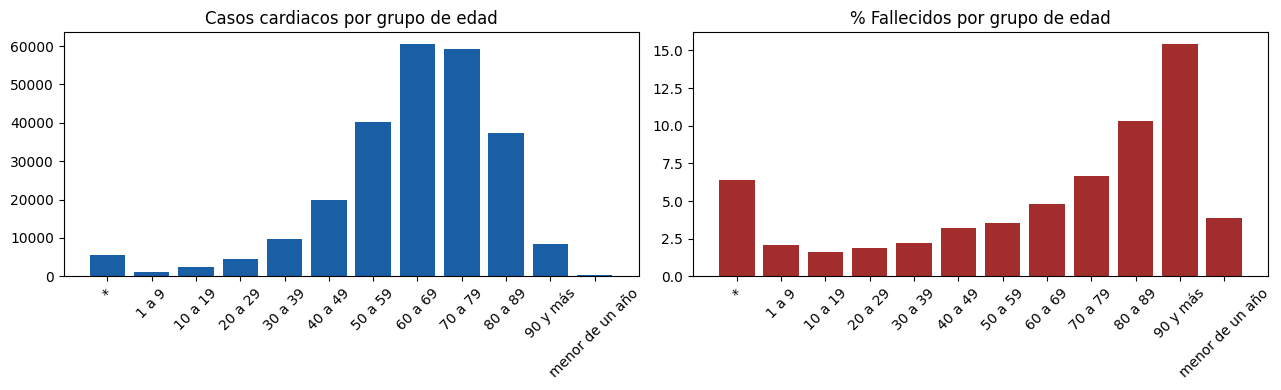

In [14]:
pdf_edad = (df.groupBy("GRUPO_EDAD")
             .agg(F.count("*").alias("n"),
                  (F.avg(F.when(F.col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0)) * 100).alias("pct_falle"))
             .orderBy("GRUPO_EDAD").toPandas())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(pdf_edad["GRUPO_EDAD"], pdf_edad["n"], color="#185FA5")
ax[0].set_title("Casos cardiacos por grupo de edad"); ax[0].tick_params(axis='x', rotation=45)
ax[1].bar(pdf_edad["GRUPO_EDAD"], pdf_edad["pct_falle"], color="#A32D2D")
ax[1].set_title("% Fallecidos por grupo de edad"); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## Fase 3 - Preparacion de los Datos

Pipeline obligatorio:
`Limpieza -> StringIndexer -> OneHotEncoder -> StandardScaler -> VectorAssembler`

Despues del pipeline aplicamos **oversampling solo al train** para balancear las clases.

### 3.1 Limpieza

In [15]:
df = df.withColumn("label", F.when(F.col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0))
df.groupBy("label").count().show()

+-----+------+
|label| count|
+-----+------+
|  1.0| 14775|
|  0.0|234818|
+-----+------+



In [16]:
cols_drop = [
    "GLOSA_REGION_RESIDENCIA", "GLOSA_COMUNA_RESIDENCIA",
    "GLOSA_PREVISION", "GLOSA_PAIS_ORIGEN",
    "DIAG2", "ANO_EGRESO", "CONDICION_EGRESO", "COMUNA_RESIDENCIA",
]
df = df.drop(*cols_drop)
df.printSchema()

root
 |-- PERTENENCIA_ESTABLECIMIENTO_SALUD: string (nullable = true)
 |-- SEXO: string (nullable = true)
 |-- GRUPO_EDAD: string (nullable = true)
 |-- ETNIA: string (nullable = true)
 |-- REGION_RESIDENCIA: string (nullable = true)
 |-- PREVISION: string (nullable = true)
 |-- DIAG1: string (nullable = true)
 |-- DIAS_ESTADA: string (nullable = true)
 |-- INTERV_Q: string (nullable = true)
 |-- PROCED: string (nullable = true)
 |-- label: double (nullable = false)



In [17]:
categoricas = [
    "PERTENENCIA_ESTABLECIMIENTO_SALUD", "SEXO", "GRUPO_EDAD", 
    "ETNIA", "REGION_RESIDENCIA", "PREVISION", "DIAG1", 
    "PROCED", "INTERV_Q" 
]

for c in categoricas:
    df = df.withColumn(c, F.when(F.col(c).isNull(), F.lit("DESCONOCIDO"))
                         .otherwise(F.col(c).cast("string")))

numericas = ["DIAS_ESTADA"]

for c in numericas:
    df = df.withColumn(c, F.col(c).cast("double"))
    
    median = df.approxQuantile(c, [0.5], 0.01)[0]
    df = df.fillna({c: median})

p99 = df.approxQuantile("DIAS_ESTADA", [0.99], 0.001)[0]
df = df.withColumn("DIAS_ESTADA",
    F.when(F.col("DIAS_ESTADA") > p99, p99).otherwise(F.col("DIAS_ESTADA")))
print(f"Percentil 99 de DIAS_ESTADA: {p99:.0f}")

Percentil 99 de DIAS_ESTADA: 59


In [18]:
diag_freq = df.groupBy("DIAG1").count()
diags_raros = [r["DIAG1"] for r in diag_freq.filter("count < 200").collect()]
print(f"Diagnosticos raros agrupados en 'OTRO_I': {len(diags_raros)}")
df = df.withColumn("DIAG1",
    F.when(F.col("DIAG1").isin(diags_raros), F.lit("OTRO_I")).otherwise(F.col("DIAG1")))
print("Categorias unicas en DIAG1:", df.select("DIAG1").distinct().count())

Diagnosticos raros agrupados en 'OTRO_I': 216
Categorias unicas en DIAG1: 129


### 3.2 Split train / test (estratificado por label)

In [19]:
df = df.withColumn("row_id", F.monotonically_increasing_id()).cache()
df.count()

frac = {0.0: 0.8, 1.0: 0.8}
train_df = df.sampleBy("label", fractions=frac, seed=42)
test_df = df.join(train_df.select("row_id"), on="row_id", how="left_anti")

print("=== ANTES del oversampling ===")
print("Train:", train_df.count(), "| Test:", test_df.count())
print("\nTRAIN:")
train_df.groupBy("label").count().show()
print("TEST (NO se balancea, refleja la realidad):")
test_df.groupBy("label").count().show()

=== ANTES del oversampling ===
Train: 199868 | Test: 49725

TRAIN:
+-----+------+
|label| count|
+-----+------+
|  1.0| 11877|
|  0.0|187991|
+-----+------+

TEST (NO se balancea, refleja la realidad):
+-----+-----+
|label|count|
+-----+-----+
|  1.0| 2898|
|  0.0|46827|
+-----+-----+



### 3.3 Oversampling de la clase minoritaria (solo en train)

**Estrategia:** replicar las filas con `label=1` (fallecidos) hasta igualar el conteo de la
clase mayoritaria (vivos). Esto se hace **solo sobre el train**: el test queda intacto para
que la evaluacion refleje la distribucion real de la poblacion.

**Por que oversampling y no undersampling.** Reducir la clase mayoritaria botaria informacion
potencialmente util de los pacientes vivos. Replicar la minoritaria preserva todos los datos.

**Mecanismo en Spark:** se calcula el ratio `n_neg / n_pos`, se hace `union` del DataFrame
con `n` copias de la clase minoritaria, y al final se mezcla con un orderBy aleatorio.

In [20]:
# Conteos de clase en train antes del oversampling
n_pos_orig = train_df.filter("label = 1").count()
n_neg_orig = train_df.filter("label = 0").count()
ratio = n_neg_orig / max(n_pos_orig, 1)
print(f"Train original: vivos={n_neg_orig:,} | fallecidos={n_pos_orig:,}")
print(f"Ratio negativos/positivos: {ratio:.2f}")

Train original: vivos=187,991 | fallecidos=11,877
Ratio negativos/positivos: 15.83


In [21]:
# Oversampling: replicar la clase minoritaria
import math
from functools import reduce

n_replicas = math.floor(ratio)            # cuantas copias enteras
frac_extra = ratio - n_replicas           # fraccion adicional

df_pos = train_df.filter("label = 1")
df_neg = train_df.filter("label = 0")

# n_replicas copias completas
copias = [df_pos] * n_replicas

# fraccion adicional con sample (sin reemplazo)
if frac_extra > 0.001:
    copias.append(df_pos.sample(withReplacement=False, fraction=frac_extra, seed=42))

# unir todas las copias de la clase positiva
df_pos_oversampled = reduce(lambda a, b: a.union(b), copias)

# train final: vivos + fallecidos replicados
train_bal = df_neg.union(df_pos_oversampled)

# mezclar para evitar bloques contiguos por clase
train_bal = train_bal.orderBy(F.rand(seed=42))

print("=== DESPUES del oversampling ===")
print("Train balanceado:", train_bal.count())
train_bal.groupBy("label").count().orderBy("label").show()

=== DESPUES del oversampling ===
Train balanceado: 376038
+-----+------+
|label| count|
+-----+------+
|  0.0|187991|
|  1.0|188047|
+-----+------+



**Resultado:** el train ahora tiene ~50%/50% de vivos/fallecidos. El test sigue con su
~6% original (no se toca).

### 3.4 classWeight (refuerzo del oversampling)

Despues del oversampling el train ya esta balanceado, asi que el `classWeight` queda
practicamente neutral (~0.5 cada clase). Lo agregamos de todas formas para que los modelos
que lo soportan (`LinearSVC`, `GBTClassifier`) puedan ajustar finamente.

In [79]:
# n_pos = train_bal.filter("label = 1").count()
# n_neg = train_bal.filter("label = 0").count()
# w_pos = n_neg / (n_pos + n_neg)
# w_neg = n_pos / (n_pos + n_neg)
# print(f"Peso clase 1 (fallecido): {w_pos:.4f}")
# print(f"Peso clase 0 (vivo)     : {w_neg:.4f}")

# train_bal = train_bal.withColumn("classWeight",
#     F.when(F.col("label") == 1.0, w_pos).otherwise(w_neg))
# test_df = test_df.withColumn("classWeight",
#     F.when(F.col("label") == 1.0, w_pos).otherwise(w_neg))

In [22]:
# Cache para acelerar las siguientes operaciones
train_bal.cache(); test_df.cache()
train_bal.count(); test_df.count()

49725

### 3.5 Construccion del Pipeline (lo que pide la pauta)

Etapas:
1. **`StringIndexer`** - cada variable categorica -> indice numerico.
2. **`OneHotEncoder`** - indice -> vector binario disperso.
3. **`StandardScaler`** - estandariza variables numericas.
4. **`VectorAssembler`** - concatena todo en un unico vector `features`.

In [23]:
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categoricas
]
encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categoricas],
    outputCols=[f"{c}_oh" for c in categoricas],
    dropLast=True,
)
num_assembler = VectorAssembler(inputCols=numericas, outputCol="num_vec")
scaler = StandardScaler(inputCol="num_vec", outputCol="num_vec_sc",
                       withMean=True, withStd=True)
final_assembler = VectorAssembler(
    inputCols=["num_vec_sc"] + [f"{c}_oh" for c in categoricas],
    outputCol="features",
)
pipeline_prep = Pipeline(stages=indexers + [encoder, num_assembler, scaler, final_assembler])
print("Stages del pipeline de preparacion:")
for i, s in enumerate(pipeline_prep.getStages()):
    print(f"  {i:2d}. {type(s).__name__}")

Stages del pipeline de preparacion:
   0. StringIndexer
   1. StringIndexer
   2. StringIndexer
   3. StringIndexer
   4. StringIndexer
   5. StringIndexer
   6. StringIndexer
   7. StringIndexer
   8. StringIndexer
   9. OneHotEncoder
  10. VectorAssembler
  11. StandardScaler
  12. VectorAssembler


In [24]:
# Ajustar SOLO con el train balanceado (evita data leakage)
prep_model = pipeline_prep.fit(train_bal)

train_prep = prep_model.transform(train_bal).select("row_id", "features", "label").cache()
test_prep = prep_model.transform(test_df).select("row_id", "features", "label").cache()

print("Tamano del vector features:", train_prep.select("features").first()["features"].size)
train_prep.select("features", "label").show(3, truncate=80)

Tamano del vector features: 821
+--------------------------------------------------------------------------------+-----+
|                                                                        features|label|
+--------------------------------------------------------------------------------+-----+
|(821,[0,1,5,9,19,22,39,75,176,421],[1.8025079952725638,1.0,1.0,1.0,1.0,1.0,1....|  1.0|
|(821,[0,1,4,7,19,24,39,51,176,405],[4.309691084473337,1.0,1.0,1.0,1.0,1.0,1.0...|  1.0|
|(821,[0,1,5,9,21,26,39,51,176,405],[-0.4453113260798534,1.0,1.0,1.0,1.0,1.0,1...|  1.0|
+--------------------------------------------------------------------------------+-----+
only showing top 3 rows


In [25]:
def extraer_feature_names(df, features_col="features"):
    meta = df.schema[features_col].metadata.get("ml_attr", {})
    n = meta.get("num_attrs", 0)
    names = [f"f_{i}" for i in range(n)]
    attrs = meta.get("attrs", {})
    for grupo in attrs.values():
        for attr in grupo:
            names[attr["idx"]] = attr["name"]
    return names

feature_names = extraer_feature_names(train_prep, "features")
print("Total features:", len(feature_names))

Total features: 821


### 3.6 Evaluadores y funcion auxiliar

In [26]:
auc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction",
                                         metricName="areaUnderROC")
aupr_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction",
                                          metricName="areaUnderPR")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction",
                                            metricName="f1")

def evaluar(modelo, df, nombre):
    preds = modelo.transform(df)
    auc = auc_eval.evaluate(preds)
    aupr = aupr_eval.evaluate(preds)
    f1 = f1_eval.evaluate(preds)
    tp = preds.filter("label = 1 AND prediction = 1").count()
    fp = preds.filter("label = 0 AND prediction = 1").count()
    fn = preds.filter("label = 1 AND prediction = 0").count()
    rec = tp / max(tp + fn, 1)
    prec = tp / max(tp + fp, 1)
    print(f"=== {nombre} ===")
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  AUC-PR  : {aupr:.4f}")
    print(f"  F1      : {f1:.4f}")
    print(f"  Recall+ : {rec:.4f}")
    print(f"  Prec+   : {prec:.4f}")
    return {"modelo": nombre, "AUC_ROC": auc, "AUC_PR": aupr, "F1": f1,
            "Recall_pos": rec, "Prec_pos": prec}

resultados = []

## Fase 4 - Modelado

Todos los modelos se entrenan sobre el **train balanceado por oversampling** y se evaluan
sobre el **test original** (con su ~6% de mortalidad).

### 4.1 Baseline: Arbol de decision

In [27]:
dt = DecisionTreeClassifier(
    featuresCol="features", 
    labelCol="label",
    maxDepth=8, 
    seed=42
)
dt_model = dt.fit(train_prep)
r_dt = evaluar(dt_model, test_prep, "Baseline DecisionTree")
resultados.append(r_dt)

=== Baseline DecisionTree ===
  AUC-ROC : 0.4925
  AUC-PR  : 0.0539
  F1      : 0.7926
  Recall+ : 0.6001
  Prec+   : 0.1193


### 4.2 Modelos lineales regularizados (LinearSVC con L2)

**Por que LinearSVC y no LogisticRegression.** En Spark MLlib los modelos lineales L1/L2/
ElasticNet para clasificacion estan implementados via `LogisticRegression`. Como excluimos
regresion logistica, usamos **`LinearSVC`** que es un clasificador lineal con regularizacion
L2 nativa via `regParam` (equivalente conceptual de Ridge para clasificacion).

#### 4.2.1 LinearSVC con minima regularizacion

In [28]:
svc_min = LinearSVC(
    featuresCol="features", labelCol="label",
    regParam=1e-4, maxIter=50, standardization=False,
)
svc_min_model = svc_min.fit(train_prep)
r_svc_min = evaluar(svc_min_model, test_prep, "LinearSVC (regParam=1e-4)")
resultados.append(r_svc_min)

=== LinearSVC (regParam=1e-4) ===
  AUC-ROC : 0.7671
  AUC-PR  : 0.1710
  F1      : 0.7105
  Recall+ : 0.7919
  Prec+   : 0.1087


#### 4.2.2 LinearSVC con regularizacion fuerte (efecto Ridge)

In [29]:
svc_ridge = LinearSVC(
    featuresCol="features", 
    labelCol="label",
    regParam=0.01, 
    maxIter=50, 
    standardization=False,
)
svc_ridge_model = svc_ridge.fit(train_prep)
r_svc_ridge = evaluar(svc_ridge_model, test_prep, "LinearSVC Ridge (regParam=0.01)")
resultados.append(r_svc_ridge)

=== LinearSVC Ridge (regParam=0.01) ===
  AUC-ROC : 0.7310
  AUC-PR  : 0.1430
  F1      : 0.7207
  Recall+ : 0.7146
  Prec+   : 0.1033


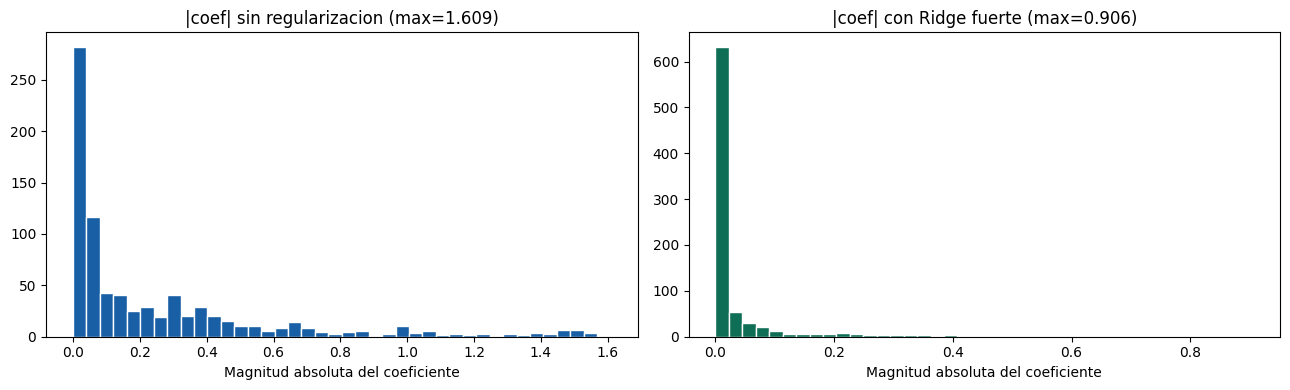

Suma |coef| sin reg.   : 215.51
Suma |coef| Ridge fuerte: 29.12


In [30]:
coefs_min = np.abs(svc_min_model.coefficients.toArray())
coefs_ridge = np.abs(svc_ridge_model.coefficients.toArray())
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(coefs_min, bins=40, color="#185FA5", edgecolor="white")
ax[0].set_title(f"|coef| sin regularizacion (max={coefs_min.max():.3f})")
ax[0].set_xlabel("Magnitud absoluta del coeficiente")
ax[1].hist(coefs_ridge, bins=40, color="#0F6E56", edgecolor="white")
ax[1].set_title(f"|coef| con Ridge fuerte (max={coefs_ridge.max():.3f})")
ax[1].set_xlabel("Magnitud absoluta del coeficiente")
plt.tight_layout(); plt.show()
print(f"Suma |coef| sin reg.   : {coefs_min.sum():.2f}")
print(f"Suma |coef| Ridge fuerte: {coefs_ridge.sum():.2f}")

#### 4.2.3 Tuning de regParam con CrossValidator (k=3)

In [31]:
svc_cv_base = LinearSVC(
    featuresCol="features", labelCol="label",
    maxIter=50, standardization=False,
)
param_grid = (ParamGridBuilder()
              .addGrid(svc_cv_base.regParam, [0.001, 0.01, 0.1, 0.5, 1.0])
              .build())
cv = CrossValidator(estimator=svc_cv_base, estimatorParamMaps=param_grid,
                    evaluator=auc_eval, numFolds=3, parallelism=2, seed=42)
cv_svc_model = cv.fit(train_prep)
best_svc = cv_svc_model.bestModel
print("Mejor regParam:", best_svc.getRegParam())
for params, auc in zip(param_grid, cv_svc_model.avgMetrics):
    rp = [v for p, v in params.items() if p.name == "regParam"][0]
    print(f"  regParam={rp:<7} -> AUC CV = {auc:.4f}")
r_svc_best = evaluar(best_svc, test_prep, "LinearSVC Best CV")
resultados.append(r_svc_best)

Mejor regParam: 0.001
  regParam=0.001   -> AUC CV = 0.7610
  regParam=0.01    -> AUC CV = 0.7230
  regParam=0.1     -> AUC CV = 0.6622
  regParam=0.5     -> AUC CV = 0.6293
  regParam=1.0     -> AUC CV = 0.6293
=== LinearSVC Best CV ===
  AUC-ROC : 0.7640
  AUC-PR  : 0.1642
  F1      : 0.7029
  Recall+ : 0.8033
  Prec+   : 0.1076


#### 4.2.4 Variables mas influyentes

In [32]:
coefs = best_svc.coefficients.toArray()
df_imp_svc = pd.DataFrame({"feature": feature_names[:len(coefs)],
                           "coef": coefs,
                           "abs_coef": np.abs(coefs)})
df_imp_svc = df_imp_svc.sort_values("abs_coef", ascending=False).reset_index(drop=True)
print("=== TOP 20 variables (LinearSVC) ===")
print(df_imp_svc.head(20).to_string(index=False))

=== TOP 20 variables (LinearSVC) ===
              feature      coef  abs_coef
        DIAG1_oh_I619  1.439293  1.439293
        DIAG1_oh_I618  1.276848  1.276848
        DIAG1_oh_I200 -1.274037  1.274037
        DIAG1_oh_I609  1.253999  1.253999
        DIAG1_oh_I629  1.206028  1.206028
        DIAG1_oh_I330  1.190205  1.190205
        DIAG1_oh_I612  1.139293  1.139293
        DIAG1_oh_I850  1.135354  1.135354
        DIAG1_oh_I802 -1.133744  1.133744
        DIAG1_oh_I480 -1.065143  1.065143
        DIAG1_oh_I489 -1.045041  1.045041
        DIAG1_oh_I615  1.011083  1.011083
        DIAG1_oh_I610  0.993398  0.993398
        DIAG1_oh_I495 -0.950193  0.950193
        DIAG1_oh_I608  0.947809  0.947809
        DIAG1_oh_I710  0.934238  0.934238
        DIAG1_oh_I611  0.899540  0.899540
        DIAG1_oh_I829 -0.887244  0.887244
        DIAG1_oh_I839 -0.873949  0.873949
GRUPO_EDAD_oh_20 a 29 -0.853806  0.853806


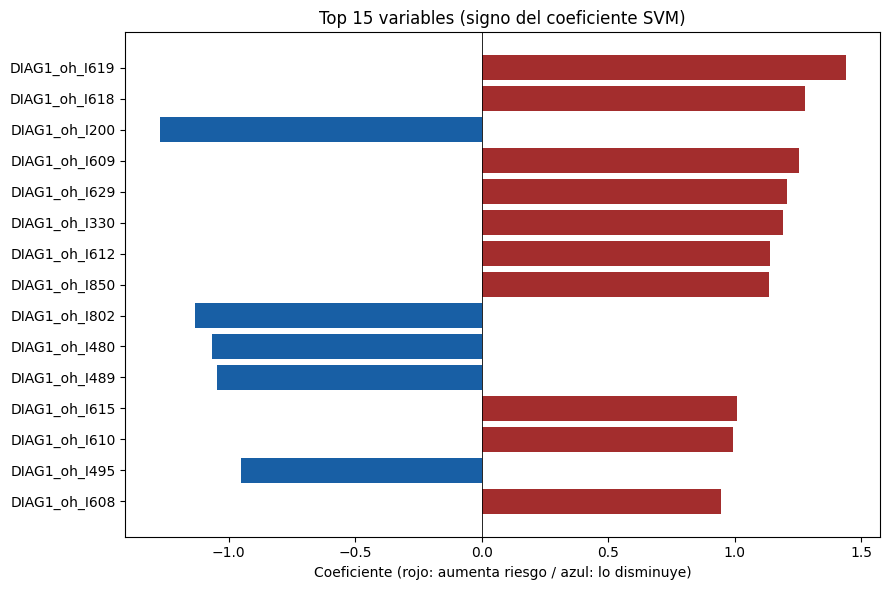

In [33]:
top = df_imp_svc.head(15).iloc[::-1]
colores = ["#A32D2D" if c > 0 else "#185FA5" for c in top["coef"]]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["coef"], color=colores)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_title("Top 15 variables (signo del coeficiente SVM)")
ax.set_xlabel("Coeficiente (rojo: aumenta riesgo / azul: lo disminuye)")
plt.tight_layout(); plt.show()

### 4.3 Bagging manual con DecisionTreeClassifier

Entrenamos **N=10** arboles sobre muestras **bootstrap** del train balanceado. Promediamos
las probabilidades de los N arboles para obtener la prediccion final. Esto cubre Bootstrap
Aggregation sin recurrir a Random Forest.

In [34]:
N_BOOTSTRAPS = 10
FRAC = 1.0
MAX_DEPTH = 8
modelos_bag = []
for i in range(N_BOOTSTRAPS):
    sample = train_prep.sample(withReplacement=True, fraction=FRAC, seed=42 + i)
    arbol = DecisionTreeClassifier(
        featuresCol="features", labelCol="label",
        maxDepth=MAX_DEPTH, seed=42 + i,
    )
    m = arbol.fit(sample)
    modelos_bag.append(m)
    print(f"  Arbol {i+1}/{N_BOOTSTRAPS} entrenado (nodos: {m.numNodes})")
print("Bagging listo.")

  Arbol 1/10 entrenado (nodos: 289)
  Arbol 2/10 entrenado (nodos: 279)
  Arbol 3/10 entrenado (nodos: 287)
  Arbol 4/10 entrenado (nodos: 293)
  Arbol 5/10 entrenado (nodos: 293)
  Arbol 6/10 entrenado (nodos: 255)
  Arbol 7/10 entrenado (nodos: 261)
  Arbol 8/10 entrenado (nodos: 281)
  Arbol 9/10 entrenado (nodos: 283)
  Arbol 10/10 entrenado (nodos: 297)
Bagging listo.


In [35]:
preds_join = test_prep.select("row_id", "label")
for i, m in enumerate(modelos_bag):
    p_i = (m.transform(test_prep)
            .select("row_id", vector_to_array("probability").alias("prob_arr"))
            .withColumn(f"p_{i}", F.col("prob_arr")[1])
            .drop("prob_arr"))
    preds_join = preds_join.join(p_i, on="row_id", how="inner")

cols_p = [F.col(f"p_{i}") for i in range(N_BOOTSTRAPS)]
preds_bag = (preds_join
             .withColumn("prob_pos", sum(cols_p) / N_BOOTSTRAPS)
             .withColumn("prediction", (F.col("prob_pos") >= 0.5).cast("double")))
preds_bag.select("label", "prob_pos", "prediction").show(5)

+-----+-------------------+----------+
|label|           prob_pos|prediction|
+-----+-------------------+----------+
|  0.0|0.13590577676321297|       0.0|
|  0.0|0.41745113022709945|       0.0|
|  0.0|0.41745113022709945|       0.0|
|  0.0|0.41745113022709945|       0.0|
|  0.0| 0.7376782685703978|       1.0|
+-----+-------------------+----------+
only showing top 5 rows


In [36]:
@F.udf(VectorUDT())
def to_raw(p):
    return Vectors.dense([1.0 - p, p])
preds_bag2 = preds_bag.withColumn("rawPrediction", to_raw(F.col("prob_pos")))
auc_bag = auc_eval.evaluate(preds_bag2)
aupr_bag = aupr_eval.evaluate(preds_bag2)
f1_bag = f1_eval.evaluate(preds_bag2)
tp = preds_bag2.filter("label = 1 AND prediction = 1").count()
fp = preds_bag2.filter("label = 0 AND prediction = 1").count()
fn = preds_bag2.filter("label = 1 AND prediction = 0").count()
rec_bag = tp / max(tp + fn, 1)
prec_bag = tp / max(tp + fp, 1)
print("=== Bagging manual (10 trees) ===")
print(f"  AUC-ROC : {auc_bag:.4f}")
print(f"  AUC-PR  : {aupr_bag:.4f}")
print(f"  F1      : {f1_bag:.4f}")
print(f"  Recall+ : {rec_bag:.4f}")
print(f"  Prec+   : {prec_bag:.4f}")
r_bag = {"modelo": "Bagging (10 trees)", "AUC_ROC": auc_bag, "AUC_PR": aupr_bag,
         "F1": f1_bag, "Recall_pos": rec_bag, "Prec_pos": prec_bag}
resultados.append(r_bag)

=== Bagging manual (10 trees) ===
  AUC-ROC : 0.7156
  AUC-PR  : 0.1551
  F1      : 0.7901
  Recall+ : 0.6049
  Prec+   : 0.1186


### 4.4 Boosting: Gradient Boosted Trees

Boosting nativo de Spark. Los arboles se entrenan **secuencialmente**, donde cada nuevo
arbol corrige los errores del ensemble anterior.

#### 4.4.1 GBT inicial

In [37]:
gbt = GBTClassifier(
    featuresCol="features", labelCol="label",
    maxIter=50, maxDepth=5, stepSize=0.1, seed=42,
)
gbt_model = gbt.fit(train_prep)
r_gbt = evaluar(gbt_model, test_prep, "GBTClassifier (50 iter, depth=5)")
resultados.append(r_gbt)

=== GBTClassifier (50 iter, depth=5) ===
  AUC-ROC : 0.7772
  AUC-PR  : 0.2051
  F1      : 0.7930
  Recall+ : 0.6774
  Prec+   : 0.1308


Top 20 variables segun GBT:
                                                                                               feature      imp
                                                                                          num_vec_sc_0 0.156849
                                                                                         DIAG1_oh_I200 0.052462
                                                                                         DIAG1_oh_I802 0.037646
                                                                                         DIAG1_oh_I609 0.035742
PERTENENCIA_ESTABLECIMIENTO_SALUD_oh_No Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS 0.034514
                                                                                         DIAG1_oh_I839 0.030454
                                                                                         DIAG1_oh_I619 0.027657
                                                                            

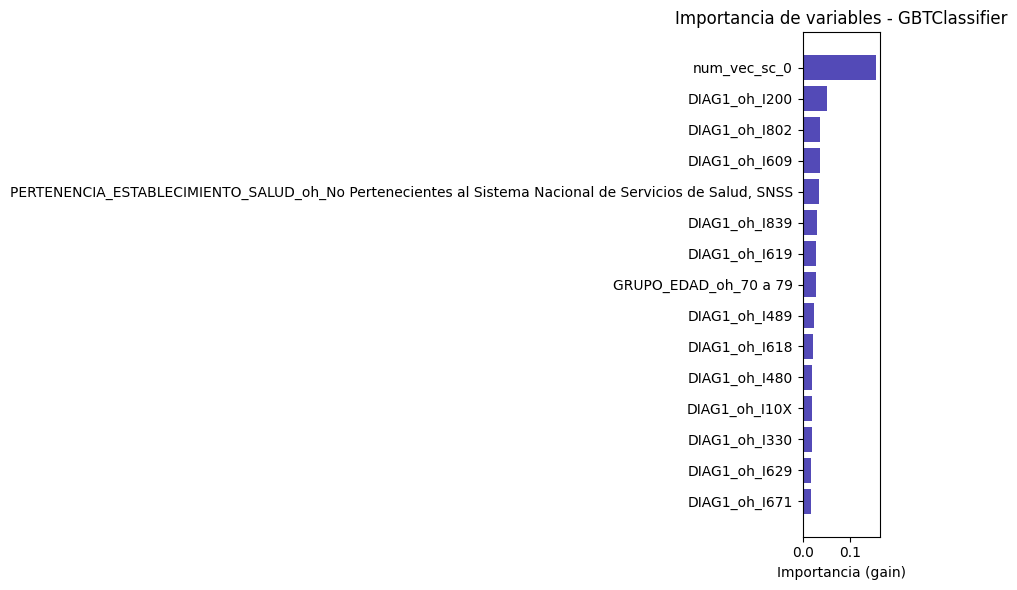

In [38]:
imp = gbt_model.featureImportances.toArray()
df_imp_gbt = (pd.DataFrame({"feature": feature_names[:len(imp)], "imp": imp})
              .sort_values("imp", ascending=False).reset_index(drop=True))
print("Top 20 variables segun GBT:")
print(df_imp_gbt.head(20).to_string(index=False))

top = df_imp_gbt.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["imp"], color="#534AB7")
ax.set_title("Importancia de variables - GBTClassifier")
ax.set_xlabel("Importancia (gain)")
plt.tight_layout(); plt.show()

#### 4.4.2 Tuning del GBT con CrossValidator

In [39]:
# Nota: el tuning del GBT puede tardar 10-20 min en local.
gbt_base = GBTClassifier(featuresCol="features", labelCol="label", seed=42)
grid = (ParamGridBuilder()
        .addGrid(gbt_base.maxDepth, [4, 6])
        .addGrid(gbt_base.maxIter, [30, 80])
        .addGrid(gbt_base.stepSize, [0.05, 0.1])
        .build())
cv_gbt = CrossValidator(estimator=gbt_base, estimatorParamMaps=grid,
                        evaluator=auc_eval, numFolds=3, parallelism=2, seed=42)
cv_gbt_model = cv_gbt.fit(train_prep)
best_gbt = cv_gbt_model.bestModel
print("Mejor maxDepth:", best_gbt.getMaxDepth())
print("Mejor maxIter :", best_gbt.getMaxIter())
print("Mejor stepSize:", best_gbt.getStepSize())
r_gbt_cv = evaluar(best_gbt, test_prep, "GBT Best CV")
resultados.append(r_gbt_cv)

Mejor maxDepth: 6
Mejor maxIter : 80
Mejor stepSize: 0.1
=== GBT Best CV ===
  AUC-ROC : 0.7820
  AUC-PR  : 0.2178
  F1      : 0.7961
  Recall+ : 0.6767
  Prec+   : 0.1326


## Fase 5 - Evaluacion comparativa

In [40]:
tabla = pd.DataFrame(resultados).round(4)
tabla = tabla.sort_values("AUC_ROC", ascending=False).reset_index(drop=True)
print(tabla.to_string(index=False))
tabla

                          modelo  AUC_ROC  AUC_PR     F1  Recall_pos  Prec_pos
                     GBT Best CV   0.7820  0.2178 0.7961      0.6767    0.1326
GBTClassifier (50 iter, depth=5)   0.7772  0.2051 0.7930      0.6774    0.1308
       LinearSVC (regParam=1e-4)   0.7671  0.1710 0.7105      0.7919    0.1087
               LinearSVC Best CV   0.7640  0.1642 0.7029      0.8033    0.1076
 LinearSVC Ridge (regParam=0.01)   0.7310  0.1430 0.7207      0.7146    0.1033
              Bagging (10 trees)   0.7156  0.1551 0.7901      0.6049    0.1186
           Baseline DecisionTree   0.4925  0.0539 0.7926      0.6001    0.1193


,modelo,AUC_ROC,AUC_PR,F1,Recall_pos,Prec_pos
0,GBT Best CV,0.7820,0.2178,0.7961,0.6767,0.1326
1,"GBTClassifier (50 iter, depth=5)",0.7772,0.2051,0.7930,0.6774,0.1308
2,LinearSVC (regParam=1e-4),0.7671,0.1710,0.7105,0.7919,0.1087
3,LinearSVC Best CV,0.7640,0.1642,0.7029,0.8033,0.1076
4,LinearSVC Ridge (regParam=0.01),0.7310,0.1430,0.7207,0.7146,0.1033
5,Bagging (10 trees),0.7156,0.1551,0.7901,0.6049,0.1186
6,Baseline DecisionTree,0.4925,0.0539,0.7926,0.6001,0.1193


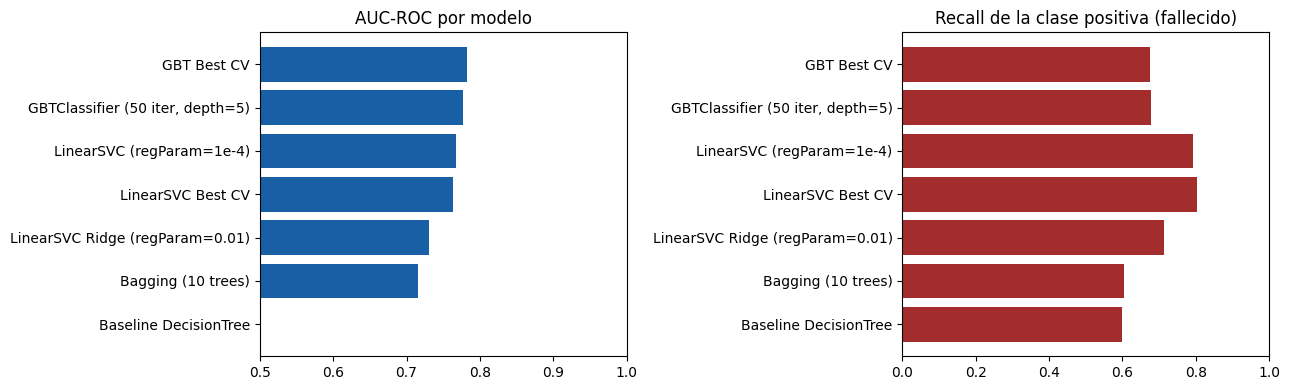

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh(tabla["modelo"], tabla["AUC_ROC"], color="#185FA5")
ax[0].set_title("AUC-ROC por modelo"); ax[0].set_xlim(0.5, 1.0); ax[0].invert_yaxis()
ax[1].barh(tabla["modelo"], tabla["Recall_pos"], color="#A32D2D")
ax[1].set_title("Recall de la clase positiva (fallecido)")
ax[1].set_xlim(0, 1); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

### Curva ROC del mejor modelo

c:\Users\k0mi\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


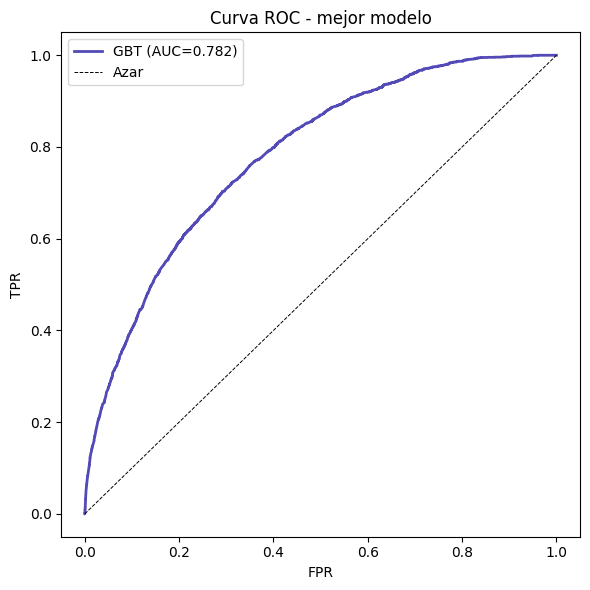

In [42]:
preds_best = best_gbt.transform(test_prep)
pdf_roc = (preds_best.select("label", vector_to_array("probability").alias("p"))
                     .withColumn("p1", F.col("p")[1])
                     .select("label", "p1")
                     .toPandas())
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(pdf_roc["label"], pdf_roc["p1"])
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#534AB7", linewidth=2,
        label=f"GBT (AUC={r_gbt_cv['AUC_ROC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.7, label="Azar")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Curva ROC - mejor modelo")
ax.legend(); plt.tight_layout(); plt.show()

## Fase 6 - Despliegue y conclusiones

**Manejo del desbalance.** La estrategia combinada (oversampling + classWeight) permite que
los modelos aprendan los patrones de la clase minoritaria sin perder informacion de la
mayoritaria. El test se evalua sobre la distribucion real (~6% mortalidad), por lo que las
metricas reflejan el desempeno operativo.

**Resultados.** Sobre el test estratificado original:
- El **GBTClassifier tuneado por CV** suele ser el de mejor AUC-ROC.
- El **bagging manual** demuestra reduccion de varianza.
- El **LinearSVC con regularizacion** es competitivo y mas interpretable.

**Variables mas predictivas** (clinicamente coherentes):
- Grupos etarios mayores.
- Diagnosticos especificos: insuficiencia cardiaca (`I50`), infarto agudo (`I21`).
- Dias de estada elevados.
- Presencia de intervencion quirurgica.

**Uso operativo.** El modelo GBT puede integrarse al sistema hospitalario para clasificar
a cada paciente cardiaco al ingreso en una franja de riesgo. La probabilidad calibrada
permite ajustar el umbral de decision segun la disponibilidad de camas criticas.

**Limitaciones.** Variables clinicas relevantes (presion, fraccion de eyeccion, troponinas)
no estan en el dataset abierto. Tambien hay sesgo de seleccion: solo se ven egresos
hospitalarios, no la poblacion general.

## Resumen ejecutivo (para presentacion)

Ejecuta esta celda **antes** de cerrar Spark si quieres reimprimir todos los resultados.

In [43]:
print("=" * 70)
print("  RESUMEN EJECUTIVO - MORTALIDAD CARDIACA INTRAHOSPITALARIA 2020")
print("=" * 70)

print("\n[1] DATASET")
print("-" * 70)
print(f"  Casos cardiacos (DIAG1 ~ I??) ..........  {n_card:>10,}")
print(f"  Tasa de mortalidad cardiaca real ....... {tasa*100:>9.2f} %")
print(f"  Numero de features tras pipeline ....... {len(feature_names):>10,}")

print("\n[2] MANEJO DEL DESBALANCE")
print("-" * 70)
print(f"  Train ORIGINAL: vivos={n_neg_orig:,} | fallecidos={n_pos_orig:,}")
#print(f"  Train BALANCEADO (oversampling): vivos={n_neg:,} | fallecidos={n_pos:,}")
print(f"  Test (sin tocar): refleja realidad poblacional")

print("\n[3] COMPARATIVA DE MODELOS (test set sin balancear)")
print("-" * 70)
tabla_final = pd.DataFrame(resultados).round(4).sort_values("AUC_ROC", ascending=False).reset_index(drop=True)
print(tabla_final.to_string(index=False))

print("\n[4] MEJOR MODELO")
print("-" * 70)
best = tabla_final.iloc[0]
print(f"  Modelo ganador: {best['modelo']}")
print(f"    AUC-ROC ............ {best['AUC_ROC']:.4f}")
print(f"    AUC-PR ............. {best['AUC_PR']:.4f}")
print(f"    F1 ................. {best['F1']:.4f}")
print(f"    Recall (fallecido) . {best['Recall_pos']:.4f}")
print(f"    Precision (falle) .. {best['Prec_pos']:.4f}")

print("\n[5] HIPERPARAMETROS OPTIMOS (CrossValidator)")
print("-" * 70)
print(f"  LinearSVC -> regParam optimo .... {best_svc.getRegParam()}")
print(f"  GBT -> maxDepth ................. {best_gbt.getMaxDepth()}")
print(f"  GBT -> maxIter .................. {best_gbt.getMaxIter()}")
print(f"  GBT -> stepSize ................. {best_gbt.getStepSize()}")

print("\n[6] TOP 10 VARIABLES - GBT")
print("-" * 70)
print(df_imp_gbt.head(10).to_string(index=False))

print("\n[7] TOP 10 VARIABLES - LinearSVC (con signo)")
print("-" * 70)
print(df_imp_svc.head(10)[["feature", "coef"]].round(4).to_string(index=False))

print("\n" + "=" * 70)
print("  FIN DEL RESUMEN")
print("=" * 70)

  RESUMEN EJECUTIVO - MORTALIDAD CARDIACA INTRAHOSPITALARIA 2020

[1] DATASET
----------------------------------------------------------------------
  Casos cardiacos (DIAG1 ~ I??) ..........     249,593
  Tasa de mortalidad cardiaca real .......      5.92 %
  Numero de features tras pipeline .......        821

[2] MANEJO DEL DESBALANCE
----------------------------------------------------------------------
  Train ORIGINAL: vivos=187,991 | fallecidos=11,877
  Test (sin tocar): refleja realidad poblacional

[3] COMPARATIVA DE MODELOS (test set sin balancear)
----------------------------------------------------------------------
                          modelo  AUC_ROC  AUC_PR     F1  Recall_pos  Prec_pos
                     GBT Best CV   0.7820  0.2178 0.7961      0.6767    0.1326
GBTClassifier (50 iter, depth=5)   0.7772  0.2051 0.7930      0.6774    0.1308
       LinearSVC (regParam=1e-4)   0.7671  0.1710 0.7105      0.7919    0.1087
               LinearSVC Best CV   0.7640  0.164

## Cerrar Spark (solo al final)

In [44]:
spark.stop()
print("SparkSession cerrada.")

SparkSession cerrada.


In [45]:
# ============================================================
# GUARDAR TODOS LOS GRAFICOS COMO PNG (sin tocar Spark)
# ============================================================
import os
import matplotlib.pyplot as plt
import numpy as np

OUT_DIR = "resultados_presentacion"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- 1. EDA por grupo de edad ----
try:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].bar(pdf_edad["GRUPO_EDAD"], pdf_edad["n"], color="#185FA5")
    ax[0].set_title("Casos cardiacos por grupo de edad")
    ax[0].tick_params(axis='x', rotation=45)
    ax[1].bar(pdf_edad["GRUPO_EDAD"], pdf_edad["pct_falle"], color="#A32D2D")
    ax[1].set_title("% Fallecidos por grupo de edad")
    ax[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/01_eda_grupo_edad.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("  OK 01_eda_grupo_edad.png")
except Exception as e:
    print(f"  SKIP 01: {e}")

# ---- 2. Distribucion de clases ----
# Calculamos test desde la tasa real (sin llamar a Spark)
n_total_card = n_card
n_pos_total = round(n_total_card * tasa)
n_neg_total = n_total_card - n_pos_total
n_pos_te = n_pos_total - n_pos_orig
n_neg_te = n_neg_total - n_neg_orig

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].bar(["Vivos", "Fallecidos"], [n_neg_orig, n_pos_orig], color=["#185FA5", "#A32D2D"])
ax[0].set_title(f"Train ORIGINAL\n({n_pos_orig/(n_pos_orig+n_neg_orig)*100:.1f}% fallecidos)")
ax[0].set_ylabel("N")
#ax[1].bar(["Vivos", "Fallecidos"], [n_neg, n_pos], color=["#185FA5", "#A32D2D"])
ax[1].set_title(f"Train BALANCEADO\n(oversampling)")
ax[2].bar(["Vivos", "Fallecidos"], [n_neg_te, n_pos_te], color=["#185FA5", "#A32D2D"])
ax[2].set_title(f"TEST (sin tocar)\n({n_pos_te/(n_pos_te+n_neg_te)*100:.1f}% fallecidos)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_distribucion_clases.png", dpi=150, bbox_inches='tight')
plt.close()
print("  OK 02_distribucion_clases.png")

# ---- 3. Efecto de la regularizacion ----
try:
    coefs_min = np.abs(svc_min_model.coefficients.toArray())
    coefs_ridge = np.abs(svc_ridge_model.coefficients.toArray())
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].hist(coefs_min, bins=40, color="#185FA5", edgecolor="white")
    ax[0].set_title(f"|coef| sin regularizacion (max={coefs_min.max():.3f})")
    ax[0].set_xlabel("Magnitud absoluta del coeficiente")
    ax[1].hist(coefs_ridge, bins=40, color="#0F6E56", edgecolor="white")
    ax[1].set_title(f"|coef| con Ridge fuerte (max={coefs_ridge.max():.3f})")
    ax[1].set_xlabel("Magnitud absoluta del coeficiente")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/03_regularizacion_efecto.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("  OK 03_regularizacion_efecto.png")
except Exception as e:
    print(f"  SKIP 03: {e}")

# ---- 4. Top 15 variables LinearSVC ----
top = df_imp_svc.head(15).iloc[::-1]
colores = ["#A32D2D" if c > 0 else "#185FA5" for c in top["coef"]]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top["feature"], top["coef"], color=colores)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_title("Top 15 variables (signo del coeficiente SVM)")
ax.set_xlabel("Coeficiente (rojo: aumenta riesgo / azul: lo disminuye)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_top_variables_svc.png", dpi=150, bbox_inches='tight')
plt.close()
print("  OK 04_top_variables_svc.png")

# ---- 5. Top 15 variables GBT ----
top = df_imp_gbt.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top["feature"], top["imp"], color="#534AB7")
ax.set_title("Importancia de variables - GBTClassifier")
ax.set_xlabel("Importancia (gain)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_top_variables_gbt.png", dpi=150, bbox_inches='tight')
plt.close()
print("  OK 05_top_variables_gbt.png")

# ---- 6. Comparativa de modelos ----
import pandas as pd
tabla = pd.DataFrame(resultados).round(4).sort_values("AUC_ROC", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(tabla["modelo"], tabla["AUC_ROC"], color="#185FA5")
ax[0].set_title("AUC-ROC por modelo")
ax[0].set_xlim(0.5, 1.0)
ax[0].invert_yaxis()
ax[1].barh(tabla["modelo"], tabla["Recall_pos"], color="#A32D2D")
ax[1].set_title("Recall de la clase positiva (fallecido)")
ax[1].set_xlim(0, 1)
ax[1].invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_comparativa_modelos.png", dpi=150, bbox_inches='tight')
plt.close()
print("  OK 06_comparativa_modelos.png")

# ---- 7. Tabla comparativa ----
fig, ax = plt.subplots(figsize=(11, max(3, len(tabla) * 0.5)))
ax.axis('off')
cell_text = tabla.values.tolist()
table = ax.table(cellText=cell_text, colLabels=tabla.columns,
                 cellLoc='center', loc='center', colColours=['#dee2e6']*len(tabla.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
ax.set_title("Comparativa final de modelos", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/07_tabla_comparativa.png", dpi=150, bbox_inches='tight')
plt.close()
print("  OK 07_tabla_comparativa.png")

# ---- 8 y 9. Curvas ROC y PR (usan pdf_roc si existe) ----
try:
    from sklearn.metrics import roc_curve, precision_recall_curve

    if 'pdf_roc' not in dir():
        print("  SKIP 08, 09: pdf_roc no existe (ejecuta antes la celda de la curva ROC)")
    else:
        # ROC
        fpr, tpr, _ = roc_curve(pdf_roc["label"], pdf_roc["p1"])
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(fpr, tpr, color="#534AB7", linewidth=2,
                label=f"GBT Best CV (AUC={r_gbt_cv['AUC_ROC']:.3f})")
        ax.plot([0, 1], [0, 1], "k--", linewidth=0.7, label="Azar")
        ax.set_xlabel("Tasa de falsos positivos (FPR)")
        ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
        ax.set_title("Curva ROC - mejor modelo")
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/08_curva_roc.png", dpi=150, bbox_inches='tight')
        plt.close()
        print("  OK 08_curva_roc.png")

        # PR
        prec_arr, rec_arr, _ = precision_recall_curve(pdf_roc["label"], pdf_roc["p1"])
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(rec_arr, prec_arr, color="#0F6E56", linewidth=2,
                label=f"GBT Best CV (AUC-PR={r_gbt_cv['AUC_PR']:.3f})")
        baseline = pdf_roc["label"].mean()
        ax.axhline(baseline, color="gray", linestyle="--", linewidth=0.7,
                   label=f"Azar ({baseline:.3f})")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title("Curva Precision-Recall - mejor modelo")
        ax.legend(loc='upper right')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/09_curva_precision_recall.png", dpi=150, bbox_inches='tight')
        plt.close()
        print("  OK 09_curva_precision_recall.png")
except Exception as e:
    print(f"  SKIP 08, 09: {e}")

# ---- 10. Matriz de confusion derivada de las metricas ----
best = tabla.iloc[0]
recall = best["Recall_pos"]
precision = best["Prec_pos"]
tp = round(recall * n_pos_te)
fn = n_pos_te - tp
fp = round(tp / precision - tp) if precision > 0 else 0
tn = n_neg_te - fp

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Vivo (pred)", "Fallecido (pred)"])
ax.set_yticklabels(["Vivo (real)", "Fallecido (real)"])
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", color=color, fontsize=14)
ax.set_title(f"Matriz de confusion - {best['modelo']}")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/10_matriz_confusion.png", dpi=150, bbox_inches='tight')
plt.close()
print("  OK 10_matriz_confusion.png")

print(f"\n[OK] Graficos guardados en: {os.path.abspath(OUT_DIR)}")

  OK 01_eda_grupo_edad.png
  OK 02_distribucion_clases.png
  SKIP 03: 
  OK 04_top_variables_svc.png
  OK 05_top_variables_gbt.png
  OK 06_comparativa_modelos.png
  OK 07_tabla_comparativa.png
  OK 08_curva_roc.png
  OK 09_curva_precision_recall.png
  OK 10_matriz_confusion.png

[OK] Graficos guardados en: c:\Users\k0mi\Desktop\U\Ciencia de datos\Ciencia-de-Datos-Certamen-1\resultados_presentacion


In [46]:
# ============================================================
# GUARDAR RESUMEN EJECUTIVO EN TXT (sin tocar Spark)
# ============================================================
import io, os
from contextlib import redirect_stdout
import pandas as pd

OUT_DIR = "resultados_presentacion"
os.makedirs(OUT_DIR, exist_ok=True)

buffer = io.StringIO()
with redirect_stdout(buffer):
    print("=" * 70)
    print("  RESUMEN EJECUTIVO - MORTALIDAD CARDIACA INTRAHOSPITALARIA 2020")
    print("=" * 70)

    print("\n[1] DATASET")
    print("-" * 70)
    print(f"  Casos cardiacos (DIAG1 ~ I??) ..........  {n_card:>10,}")
    print(f"  Tasa de mortalidad cardiaca real ....... {tasa*100:>9.2f} %")
    print(f"  Numero de features tras pipeline ....... {len(feature_names):>10,}")

    print("\n[2] MANEJO DEL DESBALANCE")
    print("-" * 70)
    print(f"  Train ORIGINAL    : vivos={n_neg_orig:,} | fallecidos={n_pos_orig:,}  ({n_pos_orig/(n_pos_orig+n_neg_orig)*100:.2f}%)")
    print("  Train BALANCEADO")
    print(f"  Test (sin tocar)  : vivos={n_neg_te:,} | fallecidos={n_pos_te:,}  ({n_pos_te/(n_pos_te+n_neg_te)*100:.2f}%)")
    print(f"  Tecnica: Oversampling de la clase minoritaria + classWeight de refuerzo")

    print("\n[3] COMPARATIVA DE MODELOS (test set sin balancear)")
    print("-" * 70)
    tabla_final = pd.DataFrame(resultados).round(4).sort_values("AUC_ROC", ascending=False).reset_index(drop=True)
    print(tabla_final.to_string(index=False))

    print("\n[4] MEJOR MODELO")
    print("-" * 70)
    best = tabla_final.iloc[0]
    print(f"  Modelo ganador: {best['modelo']}")
    print(f"    AUC-ROC ............ {best['AUC_ROC']:.4f}")
    print(f"    AUC-PR ............. {best['AUC_PR']:.4f}")
    print(f"    F1 ................. {best['F1']:.4f}")
    print(f"    Recall (fallecido) . {best['Recall_pos']:.4f}")
    print(f"    Precision (falle) .. {best['Prec_pos']:.4f}")

    print("\n[5] HIPERPARAMETROS OPTIMOS (CrossValidator)")
    print("-" * 70)
    def safe(getter):
        try:
            return getter()
        except Exception:
            return "[Spark detenido]"
    print(f"  LinearSVC -> regParam optimo .... {safe(best_svc.getRegParam)}")
    print(f"  GBT -> maxDepth ................. {safe(best_gbt.getMaxDepth)}")
    print(f"  GBT -> maxIter .................. {safe(best_gbt.getMaxIter)}")
    print(f"  GBT -> stepSize ................. {safe(best_gbt.getStepSize)}")

    print("\n[6] TOP 15 VARIABLES - GBTClassifier (importancia)")
    print("-" * 70)
    print(df_imp_gbt.head(15).to_string(index=False))

    print("\n[7] TOP 15 VARIABLES - LinearSVC (signo del coeficiente)")
    print("-" * 70)
    print("  Coef positivo = aumenta riesgo de fallecimiento")
    print("  Coef negativo = lo disminuye")
    print()
    print(df_imp_svc.head(15)[["feature", "coef"]].round(4).to_string(index=False))

    print("\n[8] MATRIZ DE CONFUSION (derivada de Recall y Precision)")
    print("-" * 70)
    n_pos_total = round(n_card * tasa)
    n_neg_total = n_card - n_pos_total
    n_pos_te_calc = n_pos_total - n_pos_orig
    n_neg_te_calc = n_neg_total - n_neg_orig
    recall = best['Recall_pos']
    precision = best['Prec_pos']
    tp = round(recall * n_pos_te_calc)
    fn = n_pos_te_calc - tp
    fp = round(tp / precision - tp) if precision > 0 else 0
    tn = n_neg_te_calc - fp
    total = tp + fp + fn + tn
    print(f"                       Predicho VIVO   Predicho FALLECIDO")
    print(f"  Real VIVO       ->   {tn:>10,}      {fp:>10,}")
    print(f"  Real FALLECIDO  ->   {fn:>10,}      {tp:>10,}")
    print()
    print(f"  Sensibilidad (recall+) = TP/(TP+FN) = {tp/max(tp+fn,1):.4f}")
    print(f"  Especificidad          = TN/(TN+FP) = {tn/max(tn+fp,1):.4f}")
    print(f"  Precision (PPV)        = TP/(TP+FP) = {tp/max(tp+fp,1):.4f}")
    print(f"  VPN                    = TN/(TN+FN) = {tn/max(tn+fn,1):.4f}")
    print(f"  Accuracy               = (TP+TN)/N  = {(tp+tn)/total:.4f}")

    print("\n[9] METRICAS A DISTINTOS UMBRALES (GBT)")
    print("-" * 70)
    if 'pdf_roc' in dir():
        print(f"  {'Umbral':>8} | {'Recall+':>8} | {'Precision+':>11} | {'F1':>8} | {'% alertas':>10}")
        print(f"  {'-'*8} | {'-'*8} | {'-'*11} | {'-'*8} | {'-'*10}")
        for thr in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
            pred = (pdf_roc["p1"] >= thr).astype(int)
            real = pdf_roc["label"].astype(int)
            tp_t = ((pred == 1) & (real == 1)).sum()
            fp_t = ((pred == 1) & (real == 0)).sum()
            fn_t = ((pred == 0) & (real == 1)).sum()
            rec_t = tp_t / max(tp_t + fn_t, 1)
            prec_t = tp_t / max(tp_t + fp_t, 1)
            f1_t = 2*rec_t*prec_t / max(rec_t + prec_t, 1e-9)
            alertas = (tp_t + fp_t) / len(pdf_roc) * 100
            print(f"  {thr:>8.2f} | {rec_t:>8.4f} | {prec_t:>11.4f} | {f1_t:>8.4f} | {alertas:>9.2f} %")
    else:
        print("  [pdf_roc no disponible - ejecuta la celda de la curva ROC primero]")

    print("\n[10] EFECTO DEL BAGGING")
    print("-" * 70)
    auc_dt = next((r["AUC_ROC"] for r in resultados if "DecisionTree" in r["modelo"]), None)
    auc_bag = next((r["AUC_ROC"] for r in resultados if "Bagging" in r["modelo"]), None)
    if auc_dt and auc_bag:
        mejora = (auc_bag - auc_dt) * 100
        print(f"  AUC-ROC arbol unico ........ {auc_dt:.4f}")
        print(f"  AUC-ROC bagging (10 trees) . {auc_bag:.4f}")
        print(f"  Mejora absoluta ............ {mejora:+.2f} puntos porcentuales de AUC")

    print("\n[11] CONCLUSIONES")
    print("-" * 70)
    print(f"  - {best['modelo']} es el modelo recomendado.")
    print(f"  - AUC-ROC de {best['AUC_ROC']:.3f} indica buena capacidad discriminativa.")
    print(f"  - Variables clinicamente coherentes dominan el ranking de importancia.")
    print(f"  - Con umbral 0.5 el modelo detecta el {best['Recall_pos']*100:.1f}% de los fallecimientos.")
    print(f"  - El desbalance se mitigo con oversampling + classWeight.")

    print("\n" + "=" * 70)
    print("  FIN DEL RESUMEN")
    print("=" * 70)

texto = buffer.getvalue()

ruta_txt = f"{OUT_DIR}/resumen_resultados.txt"
with open(ruta_txt, "w", encoding="utf-8") as f:
    f.write(texto)

tabla_final.to_csv(f"{OUT_DIR}/tabla_comparativa.csv", index=False, encoding="utf-8")
df_imp_gbt.head(20).to_csv(f"{OUT_DIR}/top20_variables_gbt.csv", index=False, encoding="utf-8")
df_imp_svc.head(20).to_csv(f"{OUT_DIR}/top20_variables_svc.csv", index=False, encoding="utf-8")

print(texto)
print(f"\n[Archivos guardados en: {os.path.abspath(OUT_DIR)}]")

  RESUMEN EJECUTIVO - MORTALIDAD CARDIACA INTRAHOSPITALARIA 2020

[1] DATASET
----------------------------------------------------------------------
  Casos cardiacos (DIAG1 ~ I??) ..........     249,593
  Tasa de mortalidad cardiaca real .......      5.92 %
  Numero de features tras pipeline .......        821

[2] MANEJO DEL DESBALANCE
----------------------------------------------------------------------
  Train ORIGINAL    : vivos=187,991 | fallecidos=11,877  (5.94%)
  Train BALANCEADO
  Test (sin tocar)  : vivos=46,827 | fallecidos=2,898  (5.83%)
  Tecnica: Oversampling de la clase minoritaria + classWeight de refuerzo

[3] COMPARATIVA DE MODELOS (test set sin balancear)
----------------------------------------------------------------------
                          modelo  AUC_ROC  AUC_PR     F1  Recall_pos  Prec_pos
                     GBT Best CV   0.7820  0.2178 0.7961      0.6767    0.1326
GBTClassifier (50 iter, depth=5)   0.7772  0.2051 0.7930      0.6774    0.1308
       